# Random Forest Model

This notebook implements a Random Forest classifier for fraud detection.

Random Forest is a more complex model capable of capturing non-linear relationships.

Class imbalance is handled using class weighting and SMOTE

The model is evaluated using:
- Precision
- Recall
- F1-score
- ROC-AUC


In [30]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE


In [4]:
#Load data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("data loaded")

data loaded


In [5]:
#Train baseline Random Forest
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=40,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=40)

In [44]:
#Predictions
y_pred_baseline = rf_baseline.predict(X_test)

#Convert report to dict to save as csv
report = classification_report(y_test, y_pred_baseline, output_dict=True)

#Convert to DataFrame
df_report = pd.DataFrame(report).transpose()

#Save to CSV
df_report.to_csv("../results/classification_ Random_Forest_Baseline.csv")

#Metrics
print("Random Forest (Baseline)")
print(classification_report(y_test, y_pred_baseline))

Random Forest (Baseline)
              precision    recall  f1-score   support

           0       0.98      0.73      0.84      2899
           1       0.15      0.77      0.25       185

    accuracy                           0.73      3084
   macro avg       0.57      0.75      0.54      3084
weighted avg       0.93      0.73      0.80      3084



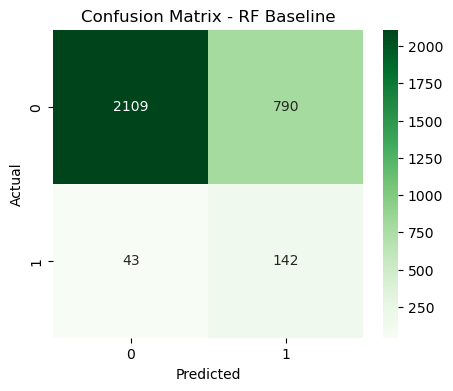

In [7]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - RF Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")

os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/rf_baseline_confusion_matrix.png", bbox_inches='tight')

plt.show()

In [8]:
#ROC_Baseline
y_proba_baseline = rf_baseline.predict_proba(X_test)[:,1]

roc_auc_baseline = roc_auc_score(y_test, y_proba_baseline)

print("ROC-AUC (Baseline):", roc_auc_baseline)

ROC-AUC (Baseline): 0.8270680476958503


In [9]:
#Apply SMOTE
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [10]:
#Train SMOTE Random Forest
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=40,
    n_jobs=-1
)

rf_smote.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=40)

In [11]:
y_pred_smote = rf_smote.predict(X_test)

#Metrics
print("Random Forest (SMOTE)")
print(classification_report(y_test, y_pred_smote))

Random Forest (SMOTE)
              precision    recall  f1-score   support

           0       0.96      0.84      0.90      2899
           1       0.16      0.48      0.24       185

    accuracy                           0.82      3084
   macro avg       0.56      0.66      0.57      3084
weighted avg       0.91      0.82      0.86      3084



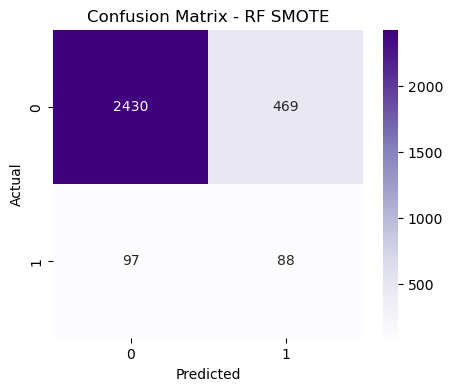

In [12]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")

plt.title("Confusion Matrix - RF SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../reports/figures/rf_smote_confusion_matrix.png", bbox_inches='tight')

plt.show()

In [13]:
#ROC_SMOTE
y_proba_smote = rf_smote.predict_proba(X_test)[:,1]

roc_auc_smote = roc_auc_score(y_test, y_proba_smote)

print("ROC-AUC (SMOTE):", roc_auc_smote)

ROC-AUC (SMOTE): 0.7978743835246078


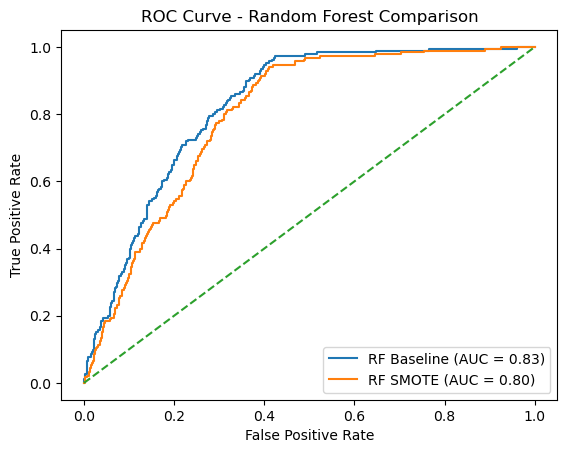

In [14]:
#ROC curve for both models

#Baseline
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_baseline)

#SMOTE
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_proba_smote)

#Plot
plt.figure()

plt.plot(fpr_base, tpr_base, label=f"RF Baseline (AUC = {roc_auc_baseline:.2f})")
plt.plot(fpr_smote, tpr_smote, label=f"RF SMOTE (AUC = {roc_auc_smote:.2f})")


plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Comparison")
plt.legend()

#Save
plt.savefig("../reports/figures/roc_curve_rf_comparison.png", bbox_inches='tight')

plt.show()

In [38]:
#Save baseline model
joblib.dump(rf_baseline, "../models/random_forest_baseline.pkl")

['../models/random_forest_baseline.pkl']

In [40]:
#Save SMOTE model
joblib.dump(rf_smote, "../models/random_forest_smote.pkl")

['../models/random_forest_smote.pkl']